# DSC 478 Assignment 1 

Written by Kira Damo

Due January 21st, 2026

## Question 1

In [1]:
#importing necessary modules for assignment

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

### Importing the data

In [2]:
adult_df = pd.read_csv('/Users/kiradamo/Documents/DSC 478/adult-modified-01-12-2025.csv')
adult_df.head(15)
#returning 15 instead of 10 to see missing value 

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,31,Self-employed,Assoc-voc,11,Divorced,Sales,Not-in-family,White,Male,40,United-States,<=50K
1,39,Private,HS-grad,9,Divorced,Other-service,Unmarried,Black,Female,40,United-States,<=50K
2,55,Private,HS-grad,9,Married,Transport-moving,Husband,White,Male,32,United-States,<=50K
3,37,Private,HS-grad,9,Married,Transport-moving,Husband,White,Male,42,United-States,<=50K
4,32,Private,HS-grad,9,Separated,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K
5,48,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,40,United-States,<=50K
6,47,Private,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,60,United-States,<=50K
7,21,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,25,United-States,<=50K
8,26,Private,Some-college,10,Married,Exec-managerial,Wife,White,Female,40,United-States,<=50K
9,60,Private,7th-8th,4,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Male,40,United-States,<=50K


### Learning the data: Summaries and Frequencies

The only numeric variables are education-num and hours-per-week

In [3]:
adult_df.describe()

,education-num,hours-per-week
count,26049.000000,26049.000000
mean,10.067411,40.412607
std,2.578405,12.327139
min,1.000000,1.000000
25%,9.000000,40.000000
50%,10.000000,40.000000
75%,12.000000,45.000000
max,16.000000,99.000000


Finding the variable types to determine the frequencies of the other variables:

In [4]:
adult_df.dtypes

age               object
workclass         object
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
hours-per-week     int64
native-country    object
income            object
dtype: object

In [5]:
adult_df['age'] = pd.to_numeric(adult_df['age'], errors='coerce')
#converting to numeric attribute

In [6]:
adult_df.describe()

,age,education-num,hours-per-week
count,26009.000000,26049.000000,26049.000000
mean,38.609558,10.067411,40.412607
std,13.639600,2.578405,12.327139
min,17.000000,1.000000,1.000000
25%,28.000000,9.000000,40.000000
50%,37.000000,10.000000,40.000000
75%,48.000000,12.000000,45.000000
max,90.000000,16.000000,99.000000


In [7]:
#if variable is an object, then pandas will calculate the count, number of unique values, the top value and how many times the top value occurs.
adult_df.astype('object').describe()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
count,26009.0,26049,26049,26049,26049,26049,26049,26049,26049,26049,26049,26049
unique,72.0,6,16,16,6,15,6,5,2,91,42,2
top,36.0,Private,HS-grad,9,Married,Prof-specialty,Husband,White,Male,40,United-States,<=50K
freq,735.0,18159,8403,8403,12046,3322,10580,22298,17442,12139,23325,19746


## Question 2

### Handling Null Values

Since all the null values are noted as "?", all these values will be replaced. Then the number of missing values for each variable can be calculated.

In [8]:
adult_df= adult_df.replace('?', np.nan)

In [9]:
adult_df.isnull().sum()

age                 40
workclass         1480
education            0
education-num        0
marital-status       0
occupation        1486
relationship         0
race                 0
sex                  0
hours-per-week       0
native-country     463
income               0
dtype: int64

In [10]:
adult_df['age'] = adult_df['age'].replace(np.nan, adult_df['age'].mean())

In [11]:
adult_df.head(15)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,31.0,Self-employed,Assoc-voc,11,Divorced,Sales,Not-in-family,White,Male,40,United-States,<=50K
1,39.0,Private,HS-grad,9,Divorced,Other-service,Unmarried,Black,Female,40,United-States,<=50K
2,55.0,Private,HS-grad,9,Married,Transport-moving,Husband,White,Male,32,United-States,<=50K
3,37.0,Private,HS-grad,9,Married,Transport-moving,Husband,White,Male,42,United-States,<=50K
4,32.0,Private,HS-grad,9,Separated,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K
5,48.0,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,40,United-States,<=50K
6,47.0,Private,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,60,United-States,<=50K
7,21.0,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,25,United-States,<=50K
8,26.0,Private,Some-college,10,Married,Exec-managerial,Wife,White,Female,40,United-States,<=50K
9,60.0,Private,7th-8th,4,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Male,40,United-States,<=50K


In [12]:
adult_df.shape
#dataframe WITH missing values

(26049, 12)

In [13]:
adult_df = adult_df.dropna()
adult_df.shape
#dataframe WITHOUT missing values

(24122, 12)

### Dropping Variables

In [14]:
adult_df.drop(['education', 'native-country'],axis=1, inplace=True)

In [15]:
adult_df.isnull().sum()
#no longer containing missing values

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64

In [16]:
adult_df.describe()
#values slightly change because of the eliminated rows that had missing values in the categorical-data columns.

,age,education-num,hours-per-week
count,24122.000000,24122.000000,24122.000000
mean,38.448652,10.109692,40.896277
std,13.125910,2.556454,11.963975
min,17.000000,1.000000,1.000000
25%,28.000000,9.000000,40.000000
50%,37.000000,10.000000,40.000000
75%,47.000000,13.000000,45.000000
max,90.000000,16.000000,99.000000


In [17]:
adult_df.astype('object').describe()

#dropped education and native-country
#Counts align with new shape size

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
count,24122.0,24122,24122,24122,24122,24122,24122,24122,24122,24122
unique,73.0,4,16,6,14,6,5,2,91,2
top,36.0,Private,9,Married,Prof-specialty,Husband,White,Male,40,<=50K
freq,692.0,17834,7864,11312,3240,10000,20777,16315,11364,18094


Finalized dataframe for the rest of the assignment:

In [18]:
adult_df.head(10)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
0,31.0,Self-employed,11,Divorced,Sales,Not-in-family,White,Male,40,<=50K
1,39.0,Private,9,Divorced,Other-service,Unmarried,Black,Female,40,<=50K
2,55.0,Private,9,Married,Transport-moving,Husband,White,Male,32,<=50K
3,37.0,Private,9,Married,Transport-moving,Husband,White,Male,42,<=50K
4,32.0,Private,9,Separated,Adm-clerical,Unmarried,White,Female,40,<=50K
5,48.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,40,<=50K
6,47.0,Private,10,Divorced,Adm-clerical,Not-in-family,White,Female,60,<=50K
7,21.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,25,<=50K
8,26.0,Private,10,Married,Exec-managerial,Wife,White,Female,40,<=50K
9,60.0,Private,4,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Male,40,<=50K


## Question 3

### Box Plots

<Axes: >

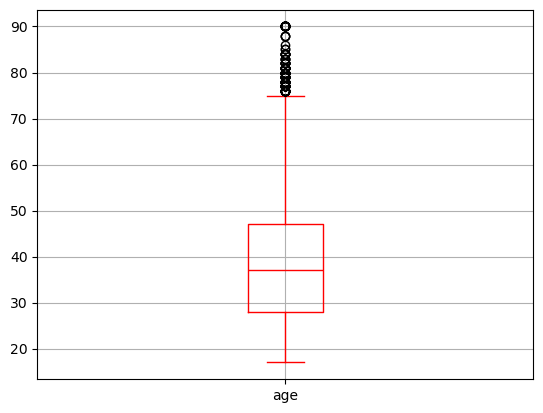

In [19]:
#box plot for age
adult_df[['age']].boxplot(color='red')

<Axes: >

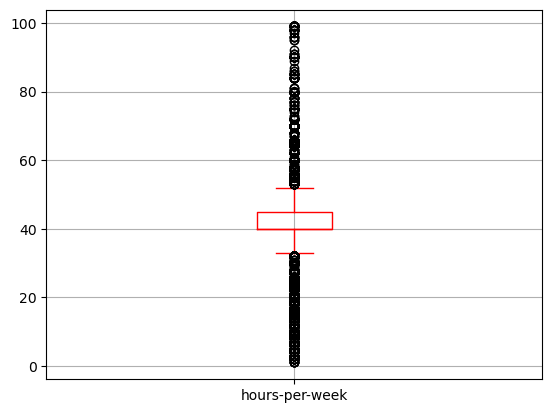

In [20]:
#box plot for hours-per-week
adult_df[['hours-per-week']].boxplot(color='red')

<Axes: >

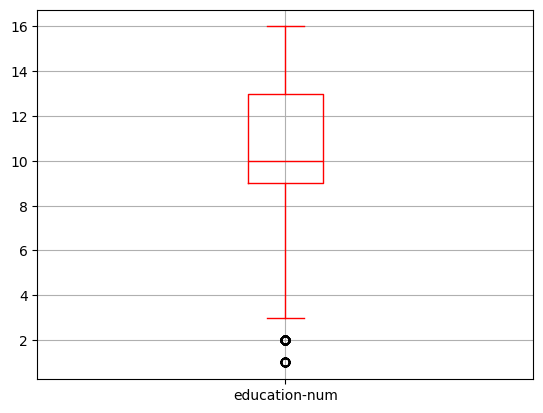

In [21]:
#box plot for education-num
adult_df[['education-num']].boxplot(color='red')

### Histograms

Creating histograms of the numeric attributes. The grid is turned off to see the shape more clearly.

array([[<Axes: title={'center': 'age'}>]], dtype=object)

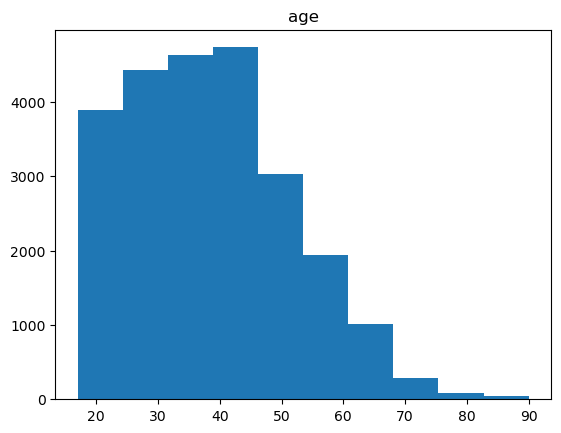

In [22]:
#histogram of age
adult_df[['age']].hist(grid=False)

array([[<Axes: title={'center': 'hours-per-week'}>]], dtype=object)

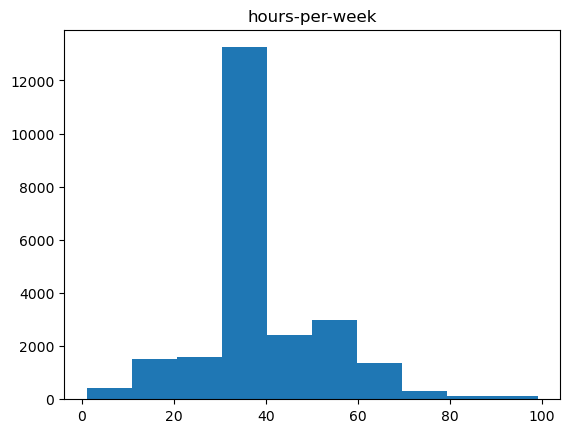

In [23]:
#histogram of hours per week
adult_df[['hours-per-week']].hist(grid=False)

array([[<Axes: title={'center': 'education-num'}>]], dtype=object)

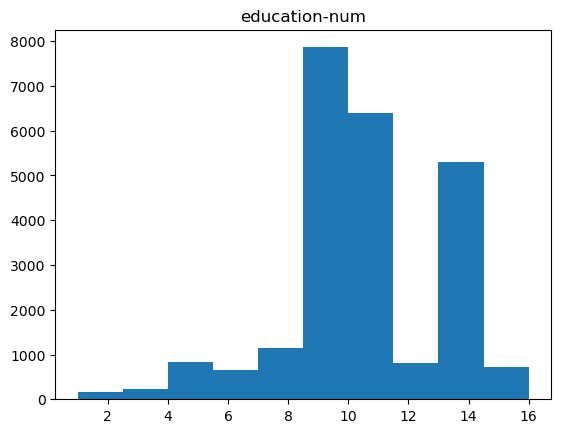

In [24]:
#histogram of education-num
adult_df[['education-num']].hist(grid=False)

### Scatter Plot

Scatter plot of education number vs age:

Text(0.5, 1.0, 'education-num vs age')

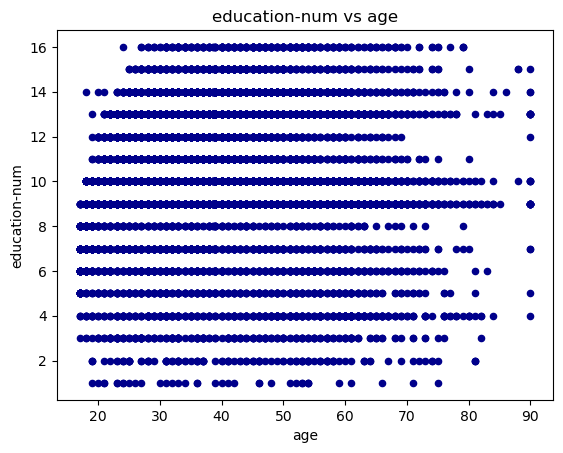

In [25]:
adult_df.plot.scatter(x='age', y='education-num', c='DarkBlue')
plt.title('education-num vs age')

## Question 4

Creating bar charts for the categorical attributes:

In [26]:
adult_df.columns
#checking all the attribute names
#bar charts for all variables except age, education-num, and hours-per-week

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'hours-per-week', 'income'],
      dtype='object')

### Bar Charts

<Axes: title={'center': 'Frequency of Each Working Class'}, xlabel='Work Class', ylabel='Count'>

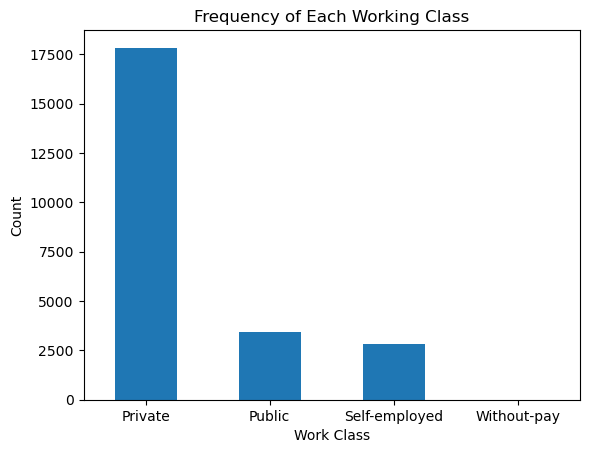

In [27]:
#work class bar chart
counts = adult_df['workclass'].value_counts()
counts.plot(kind='bar', xlabel='Work Class', ylabel='Count', title='Frequency of Each Working Class', rot=0)

<Axes: title={'center': 'Frequency of Each Marital Status'}, xlabel='Count', ylabel='Marital Status'>

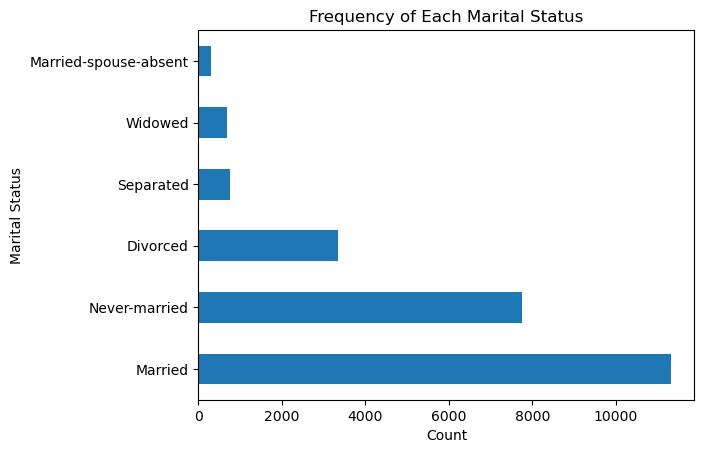

In [28]:
#marital status bar chart
counts = adult_df['marital-status'].value_counts()
counts.plot(kind='barh', xlabel='Count', ylabel='Marital Status', title='Frequency of Each Marital Status', rot=0)
#horizontal bar chart to make attributes easier to read

<Axes: title={'center': 'Frequency of Each Occupation'}, xlabel='Count', ylabel='Occupation'>

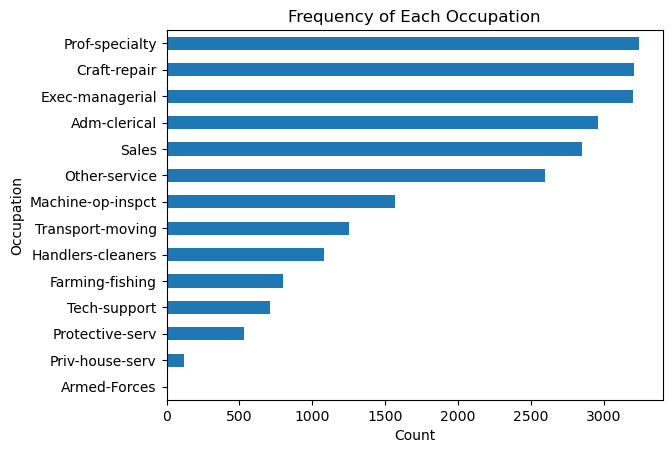

In [29]:
#occupation bar chart
counts = adult_df['occupation'].value_counts().sort_values(ascending=True)
counts.plot(kind='barh', xlabel='Count', ylabel='Occupation', title='Frequency of Each Occupation', rot=0)

<Axes: title={'center': 'Frequency of Each Relationship'}, xlabel='Count', ylabel='Relationship'>

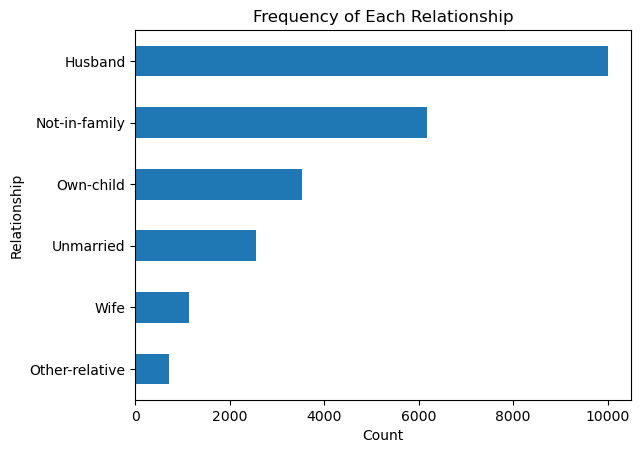

In [30]:
#Relationship bar chart
counts = adult_df['relationship'].value_counts().sort_values(ascending=True)
counts.plot(kind='barh', xlabel='Count', ylabel='Relationship', title='Frequency of Each Relationship', rot=0)
#rotating 45 degrees to make each marital staus readable

<Axes: title={'center': 'Frequency of Each Race'}, xlabel='Count', ylabel='Race'>

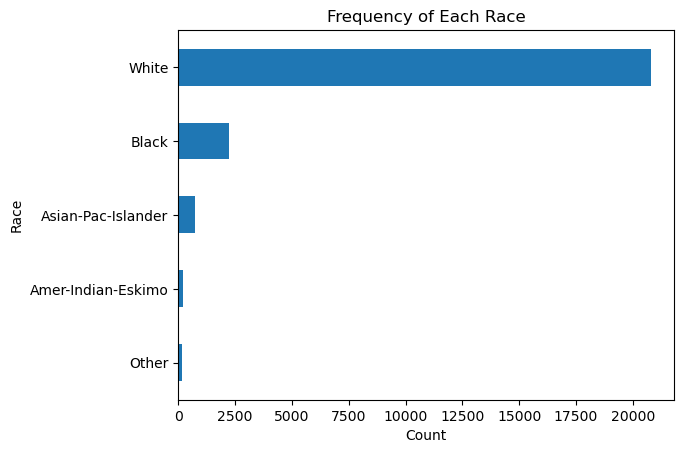

In [31]:
#Race bar chart
counts = adult_df['race'].value_counts().sort_values(ascending=True)
counts.plot(kind='barh', xlabel='Count', ylabel='Race', title='Frequency of Each Race', rot=0)
#rotating 45 degrees to make each marital staus readable

<Axes: title={'center': 'Frequency of Each Sex'}, xlabel='Count', ylabel='Sex'>

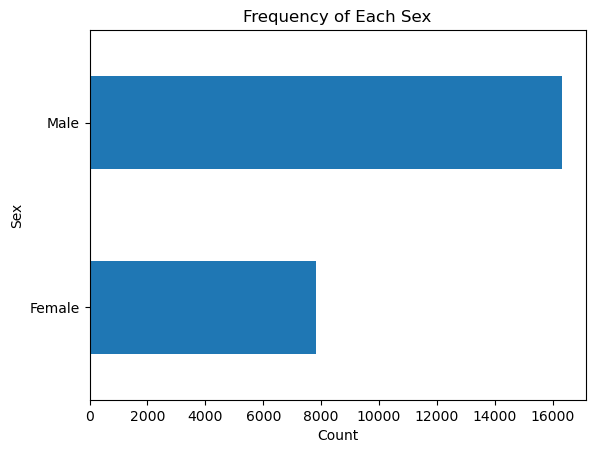

In [32]:
#Sex bar chart
counts = adult_df['sex'].value_counts().sort_values(ascending=True)
counts.plot(kind='barh', xlabel='Count', ylabel='Sex', title='Frequency of Each Sex', rot=0)
#rotating 45 degrees to make each marital staus readable

<Axes: title={'center': 'Frequency of Each Income'}, xlabel='Count', ylabel='Income'>

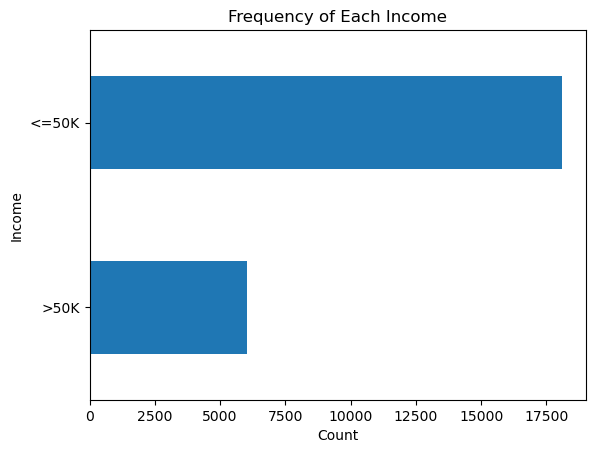

In [33]:
#Income bar chart
counts = adult_df['income'].value_counts().sort_values(ascending=True)
counts.plot(kind='barh', xlabel='Count', ylabel='Income', title='Frequency of Each Income', rot=0)
#rotating 45 degrees to make each marital staus readable

## Question 5

Cross Tabulation between workclass and income then workclass and race. Bar charts are created for each.

### Cross Tabulation Tables - Work Class and Income

In [34]:
#working class and income
ct_wi = pd.crosstab(adult_df['workclass'], adult_df['income'])
ct_wi

income,<=50K,>50K
workclass,,
Private,13914,3920
Public,2370,1063
Self-employed,1799,1045
Without-pay,11,0


Text(0.5, 1.0, 'Working Class vs Income')

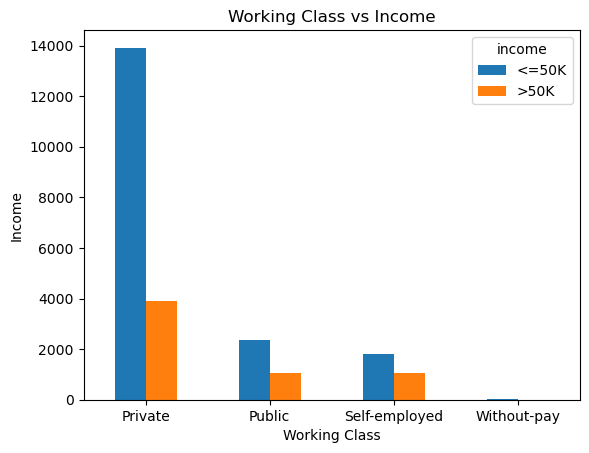

In [35]:
ct_wi.plot(kind='bar')
plt.ylabel('Income')
plt.xlabel('Working Class')
plt.xticks(rotation=0, ha='center')
plt.title('Working Class vs Income')

### Cross Tabulation Tables and Charts - Race and Income

In [36]:
#race and income
ct_ri = pd.crosstab(adult_df['race'], adult_df['income'])
ct_ri

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,199,28
Asian-Pac-Islander,525,195
Black,1929,292
Other,162,15
White,15279,5498


Text(0.5, 1.0, 'Race vs Income')

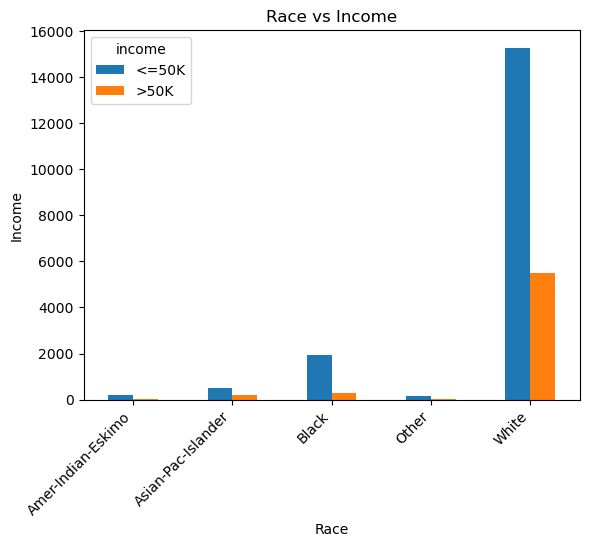

In [37]:
ct_ri.plot(kind='bar')
plt.ylabel('Income')
plt.xlabel('Race')
plt.xticks(rotation=45, ha='right')
plt.title('Race vs Income')

### Cross Tabulation Chart of Percentage of Each Race Category

Text(0.5, 1.0, 'Percentages of Each Race Category with <=50K Income')

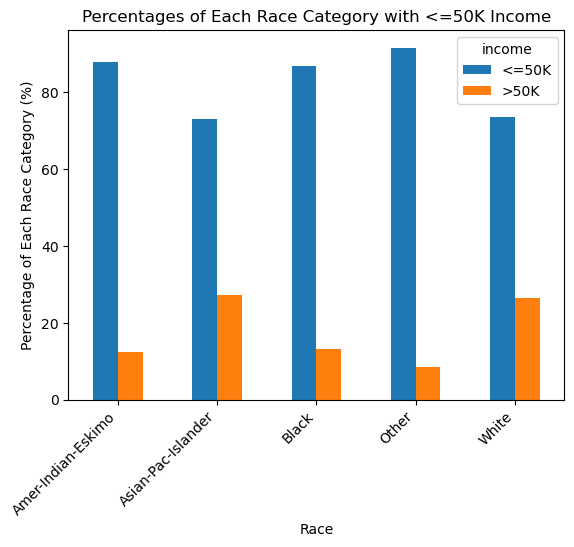

In [38]:
ct_ri_lowincome = pd.crosstab(adult_df['race'],adult_df['income'], normalize='index') * 100
#normalize calculates the portion of within each of the attributes
ct_ri_lowincome.plot(kind='bar')
plt.ylabel('Percentage of Each Race Category (%)')
plt.xlabel('Race')
plt.xticks(rotation=45, ha='right')
plt.title('Percentages of Each Race Category with <=50K Income')

## Question 6

Creating a new dataframe to identify characteristics of the data:

In [39]:
df_6 = adult_df[(adult_df['workclass'] == 'Private') & (adult_df['education-num'] < 13)]
df_6.head(10)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
1,39.0,Private,9,Divorced,Other-service,Unmarried,Black,Female,40,<=50K
2,55.0,Private,9,Married,Transport-moving,Husband,White,Male,32,<=50K
3,37.0,Private,9,Married,Transport-moving,Husband,White,Male,42,<=50K
4,32.0,Private,9,Separated,Adm-clerical,Unmarried,White,Female,40,<=50K
5,48.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,40,<=50K
6,47.0,Private,10,Divorced,Adm-clerical,Not-in-family,White,Female,60,<=50K
7,21.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,25,<=50K
8,26.0,Private,10,Married,Exec-managerial,Wife,White,Female,40,<=50K
9,60.0,Private,4,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Male,40,<=50K
10,23.0,Private,9,Never-married,Other-service,Not-in-family,White,Female,25,<=50K


To see the distribution, both a histogram and a summary of the data will be analyzed. Below is the mean, standard deviation, and the five number summary of the numeric attributes as well as the number of unique values and the most frequent characteristics within the categorical attributes. 

In [40]:
df_6.describe()
#gathering five number summary, mean, and std of numeric attributes.

,age,education-num,hours-per-week
count,14052.000000,14052.000000,14052.000000
mean,36.297192,8.913180,39.344008
std,13.137871,1.857841,11.111860
min,17.000000,1.000000,1.000000
25%,25.000000,9.000000,38.000000
50%,34.000000,9.000000,40.000000
75%,45.000000,10.000000,40.000000
max,90.000000,12.000000,99.000000


In [41]:
df_6.astype('object').describe()
#finding the most frequent qualities of each categorical attribute.

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
count,14052.0,14052,14052,14052,14052,14052,14052,14052,14052,14052
unique,70.0,1,12,6,13,6,5,2,86,2
top,23.0,Private,9,Married,Craft-repair,Husband,White,Male,40,<=50K
freq,460.0,14052,6155,5705,2369,4983,11957,9047,7113,11960


To understand the distribution and proportions of each characteristic, it is important to visualize the distribution.

Although the average age is ~36 years old, the most reoccuring age is 23. This causes the distribution to be right-skewed.

Text(0, 0.5, 'Count')

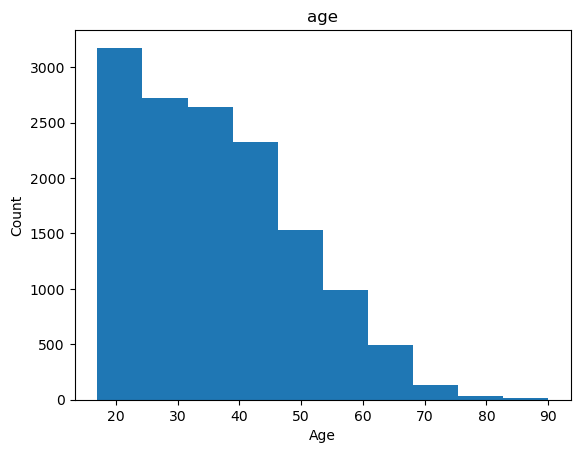

In [42]:
#distribution of age
#right skewed due to mode < mean
df_6[['age']].hist(grid=False)
plt.xlabel('Age')
plt.ylabel('Count')

The number of years of education that occurred the most was 9. On the census scale for educational attainment, 9 is a high school dimploma or equivalent (GED). An education-num under 13 indicates that this sample only completed at most an Associate's degree (13 would be a bachelor's).

Text(0, 0.5, 'Count')

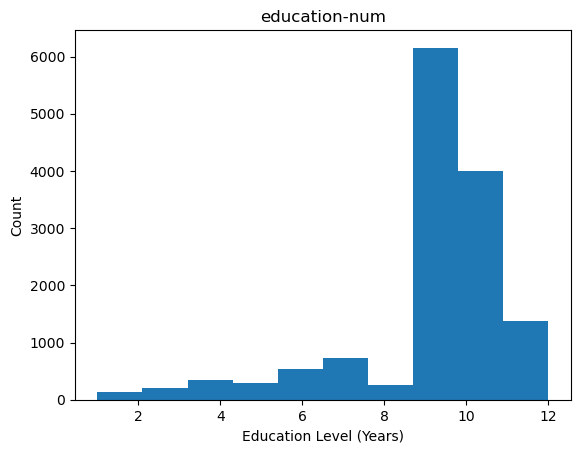

In [43]:
#distribution of education-num
#left skewed since limitation is at 13
#mean, median, and mode are similar (~9 years) which is closer to 13 than 0.
df_6[['education-num']].hist(grid=False)
plt.xlabel('Education Level (Years)')
plt.ylabel('Count')

The large majority of this sample makes $50,000 or lower.

<Axes: title={'center': 'Lower Income vs Higher Income'}, xlabel='Income', ylabel='Count'>

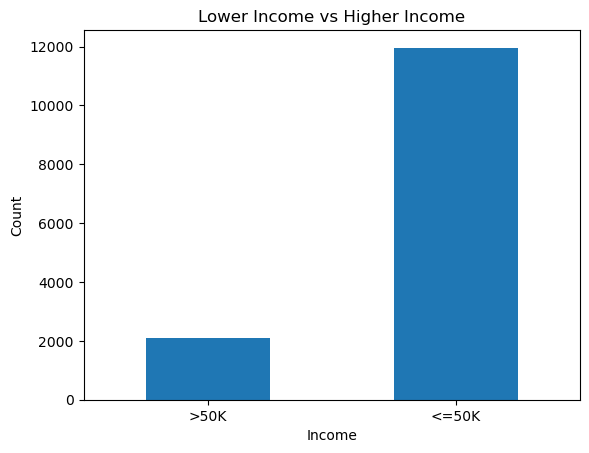

In [44]:
#bar chart of income
counts = df_6['income'].value_counts(ascending=True)
counts.plot(kind='bar', ylabel='Count', xlabel='Income', title='Lower Income vs Higher Income', rot=0)

Despite the mean and mode both being ~40 hours per week, seeing the distribution of hours per week also provides insight to the lower income population of this data. Less hours worked will result in less pay and those who work over 40 hours may have a work environment that requires them to be on-call or working longer shifts. The distribution of this attribute is also shown as a normal distribution since the median, mode, and mean are all similar.

Text(0, 0.5, 'Count')

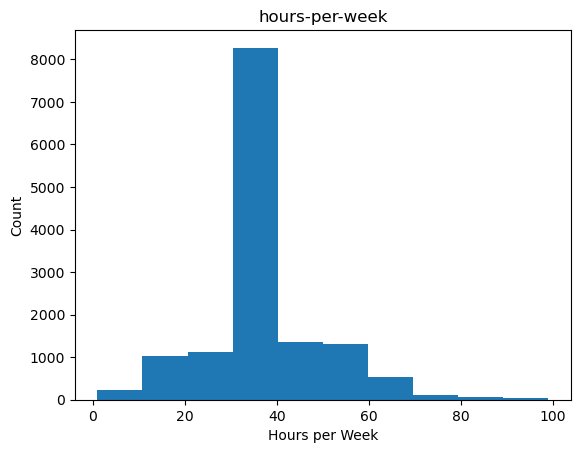

In [45]:
#distribution of hours per week
df_6[['hours-per-week']].hist(grid=False)
plt.xlabel('Hours per Week')
plt.ylabel('Count')

The occupation with the highest frequency is craft-repair followed by other-service. Many of these occupations are manual labor or service-related like transport-moving and sales. 

<Axes: title={'center': 'Frequency of Each Occupation'}, xlabel='Count', ylabel='Occupation'>

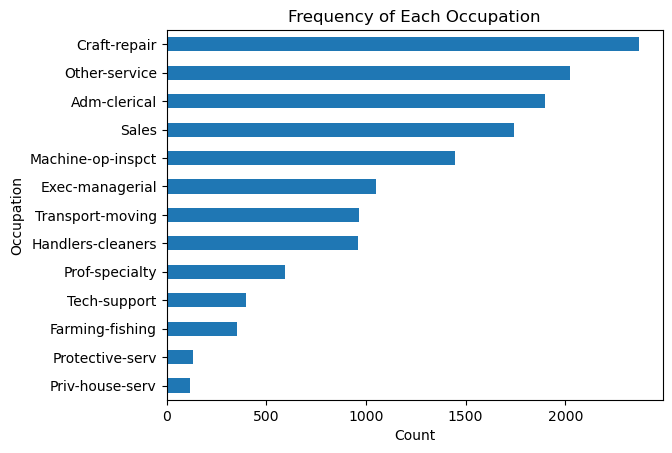

In [46]:
#sorting occupation in ascending order to clearly identify the majority
counts = df_6['occupation'].value_counts(ascending=True)
counts.plot(kind='barh', ylabel='Occupation', xlabel='Count', title='Frequency of Each Occupation', rot=0)

The last characteristics of this sample are demographics. Majority of this sample are Married and following that is never-married. 

<Axes: title={'center': 'Frequency of Each Marital Status'}, xlabel='Count', ylabel='Marital Status'>

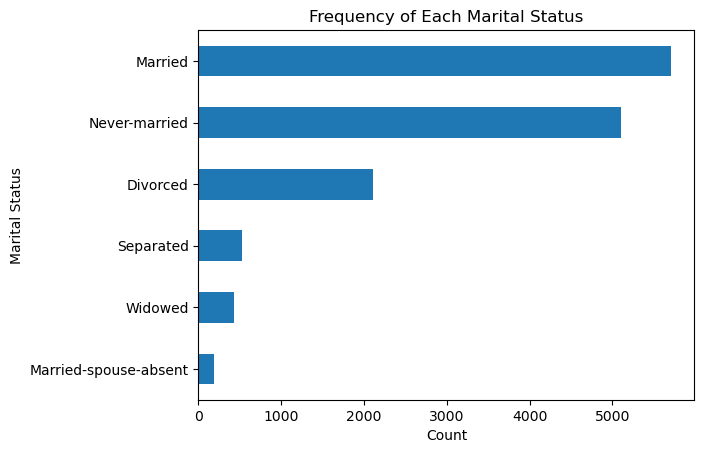

In [47]:
#sorting marital status in ascending order to clearly identify the majority
counts = df_6['marital-status'].value_counts(ascending=True)
counts.plot(kind='barh', ylabel='Marital Status', xlabel='Count', title='Frequency of Each Marital Status', rot=0)

The race that occurs most in this sample are White and following that are Black.

<Axes: title={'center': 'Frequency of Each Race'}, xlabel='Race', ylabel='Count'>

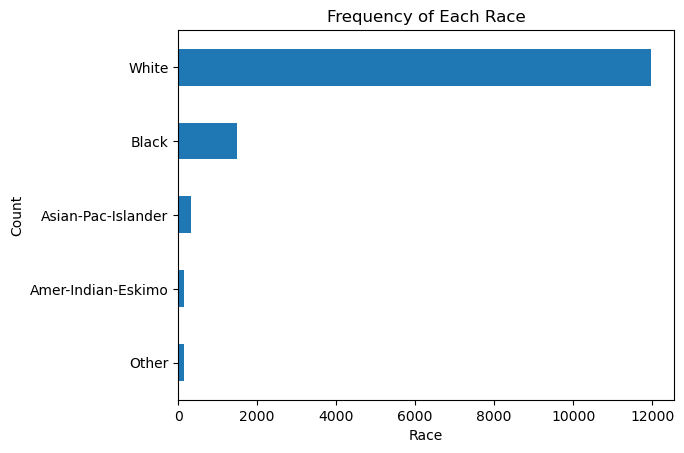

In [48]:
#sorting race in ascending order to clearly identify the majority
counts = df_6['race'].value_counts(ascending = True)
counts.plot(kind='barh', xlabel='Race', ylabel='Count', title='Frequency of Each Race', rot=0)

The sex that is most prevalent in this sample is Male.

<Axes: title={'center': 'Frequency of Each Sex'}, xlabel='Sex', ylabel='Count'>

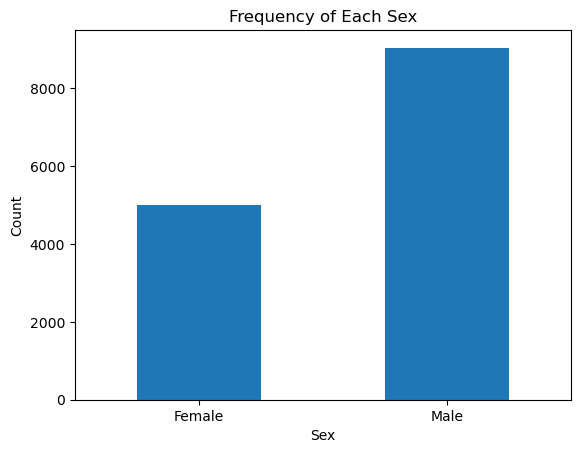

In [49]:
#bar chart of sex
counts = df_6['sex'].value_counts(ascending=True)
counts.plot(kind='bar', xlabel='Sex', ylabel='Count', title='Frequency of Each Sex', rot=0)

The demographics of the majority of this group are similar to the majority in the original census dataframe. This sample is mostly comprised of younger people in their twenties to thirties and the most prevalent race is White followed by Black. Most of this sample is also married or never married. The large majority are also men.

The dominant occupation in this sample is craft-repair followed by other-service. Many of these professions are manual labor or are service-based. The barrier to entry may not be as high as a corporate-executive work (such as having a college degree) resulting in a majority of people overall to choose that field.

A large majority of this sample makes 50,000 or less. This demonstrates a general relationship that those with less than a high school diploma may make 50,000 oor less. This idea can also be reinforced with the distribution of the work hours. The work hours are normally distributed with a large majority working 40 hours per week. Part time hours can also result in a lower income. On the other hand, those with a lower income may work more hours.

## Question 7

To compare and contrast the attributes of high income and low income, two dataframes will be made for each group:

In [50]:
low_income = adult_df[adult_df['income'] == '<=50K']
high_income = adult_df[adult_df['income'] == '>50K']

Finding the five number summary, mean, and standard deviation of all numeric attributes of low-income individuals:

In [51]:
low_income.describe()

,age,education-num,hours-per-week
count,18094.000000,18094.000000,18094.000000
mean,36.635850,9.617000,39.295954
std,13.482691,2.422967,11.924276
min,17.000000,1.000000,1.000000
25%,26.000000,9.000000,37.000000
50%,34.000000,9.000000,40.000000
75%,45.000000,10.000000,40.000000
max,90.000000,16.000000,99.000000


Finding the modes/frequencies and number of unique values for categorical attributes of low-income individuals:

In [52]:
low_income.astype('object').describe()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
count,18094.0,18094,18094,18094,18094,18094,18094,18094,18094,18094
unique,73.0,4,16,6,14,6,5,2,89,1
top,23.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Male,40,<=50K
freq,653.0,13914,6540,7375,2560,5513,15279,11173,8875,18094


Finding the five number summary, mean, and standard deviation of all numeric attributes of high-income individuals:

In [53]:
high_income.describe()

,age,education-num,hours-per-week
count,6028.000000,6028.000000,6028.000000
mean,43.890065,11.588587,45.699900
std,10.214652,2.369742,10.734994
min,19.000000,2.000000,1.000000
25%,36.000000,9.750000,40.000000
50%,43.000000,12.000000,40.000000
75%,51.000000,13.000000,50.000000
max,90.000000,16.000000,99.000000


Finding the modes/frequencies and number of unique values for categorical attributes of high-income individuals:

In [54]:
high_income.astype('object').describe()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income
count,6028.0,6028,6028,6028,6028,6028,6028,6028,6028,6028
unique,66.0,3,15,6,13,6,5,2,76,1
top,46.0,Private,13,Married,Exec-managerial,Husband,White,Male,40,>50K
freq,236.0,3920,1699,5159,1550,4576,5498,5142,2489,6028


The higher income summaries show that this group is slightly older than the lower income group. The mean age for the lower income group is ~37 years old and the higher income group's is ~44 years old. The quartiles and minimum of the high income group is larger than the low income group. Those who are older are more likely to have seniority from working experience as well as an academic background which will ultimately result in higher pay.

The mode of education level in the high income group is 13 which is at least a Bachelor's degree. On the other hand, the low income group's mode is 9 which translates to a high school diploma or GED. Additionally, those with higher income are mostly in executive-managerial positions whereas lower income individuals are mostly in administrative-clerical positions.

<Axes: xlabel='education-num'>

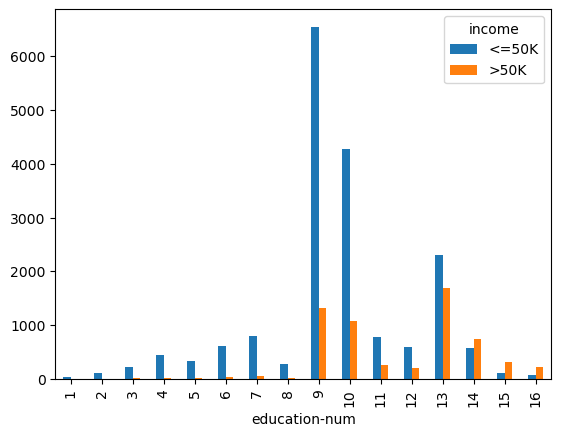

In [55]:
#High income mostly prominent in the second half of the bar chart
#in most cases, higher education-num results in higher pay
pd.crosstab(adult_df['education-num'], adult_df['income']).plot(kind='bar')

The private sector consists of many positions that do not require higher education degrees, offer hourly wages, and have limited opportunities for promotion. These include retail, warehousing, hospitality, entry-level office positions, etc. 

Although positions in all sectors have both low income and high income, private sector is the dominant working class.

<Axes: ylabel='workclass'>

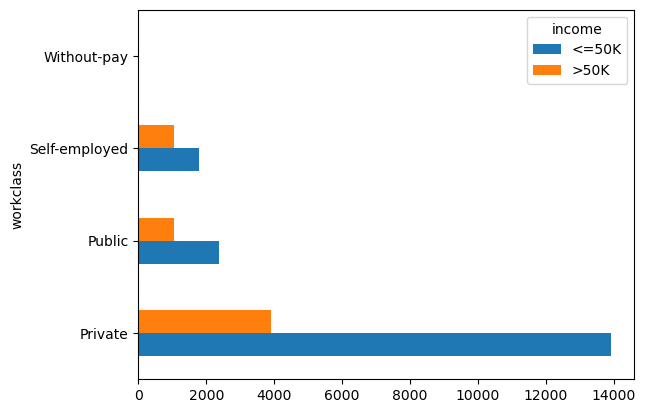

In [56]:
#horizontal bar graph
pd.crosstab(adult_df['workclass'], adult_df['income']).plot(kind='barh')

The cross tabulation below shows that low income indiviuals are in all occupations. The only occupation where high income individuals are not is priv-house-serv. There is a higher concentration of low income individuals in service and manual labor roles. 

The roles that are associated with higher levels of education are more prevalent within the high-income group.

The high-income group tends to work more hours. The low-income group has a higher count of hours less than 30 (may be part-time hours which can result in lower income).

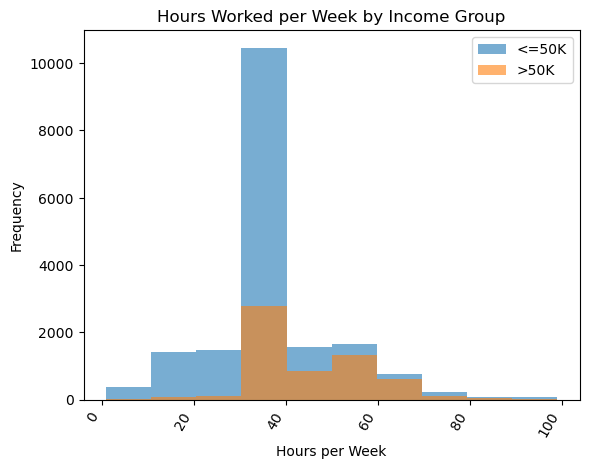

In [57]:
plt.hist(low_income['hours-per-week'], alpha=0.6, label='<=50K')
plt.hist(high_income['hours-per-week'], alpha=0.6, label='>50K')
plt.legend()
plt.xlabel('Hours per Week')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Frequency')
plt.title('Hours Worked per Week by Income Group')
plt.show()

<Axes: ylabel='occupation'>

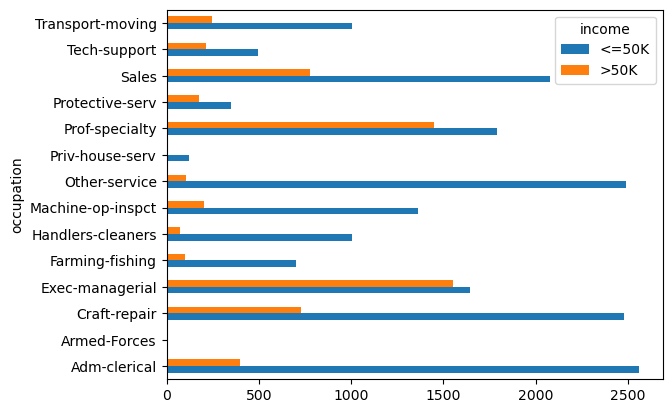

In [58]:
#horizontal bar chart so occupations are easier to read
pd.crosstab(adult_df['occupation'], adult_df['income']).plot(kind='barh')

A large majority of the sample is White. The ratio of low income to high income for all races is large especially for White and Black individuals. 

<Axes: ylabel='race'>

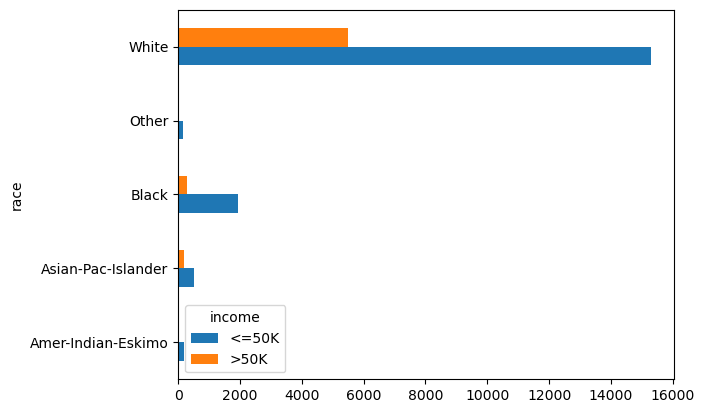

In [59]:
pd.crosstab(adult_df['race'], adult_df['income']).plot(kind='barh')

The proportion of men to women is much higher in high income than in low income.

<Axes: xlabel='sex'>

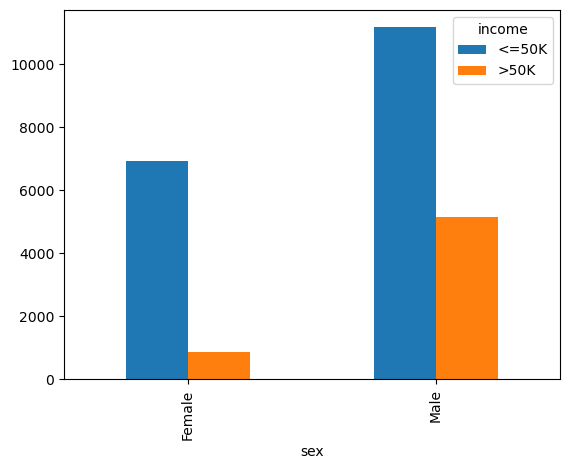

In [60]:
pd.crosstab(adult_df['sex'], adult_df['income']).plot(kind='bar')

The proportion of married to never-married high-income individuals is much larger than the low-income's.

<Axes: ylabel='marital-status'>

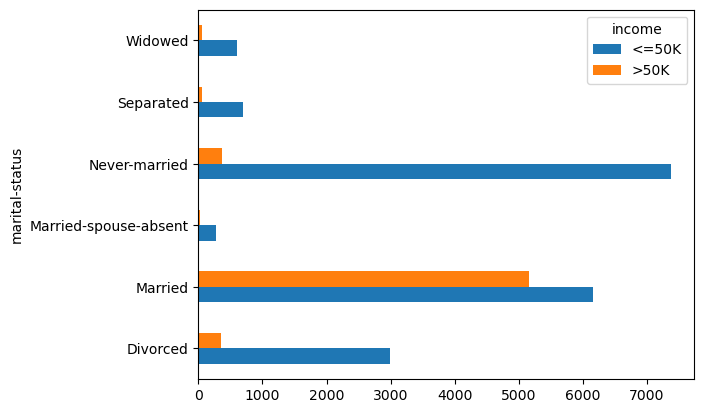

In [61]:
pd.crosstab(adult_df['marital-status'], adult_df['income']).plot(kind='barh')

From these cross tabulations and summaries of both groups, individuals with a higher income, >50K, are more likely to be older, work more hours, and more educated. In contrast, individuals with a lower income are younger and mostly have a high school diploma or equivalent. 

## Question 8

In [62]:
#converting data to binaries with dummy variables
#enc = encoded
adult_df_enc = pd.get_dummies(adult_df).astype(int)
adult_df_enc.head(10)
#numeric attributes remain the same but all categorical attributes are boolean values

,age,education-num,hours-per-week,workclass_Private,workclass_Public,workclass_Self-employed,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Married-spouse-absent,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,31,11,40,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,1,1,0
1,39,9,40,1,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0
2,55,9,32,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,1,0
3,37,9,42,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,1,0
4,32,9,40,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
5,48,9,40,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
6,47,10,60,1,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,1,0
7,21,9,25,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
8,26,10,40,1,0,0,0,0,1,0,...,1,0,0,0,0,1,1,0,1,0
9,60,4,40,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,0


In [63]:
adult_df_enc.to_csv('adult_numeric.csv')
#saving as a csv named adult_numeric

## Question 9

In [64]:
adult_numeric = pd.read_csv('adult_numeric.csv', index_col=0)
adult_numeric.head(15)
#returning 15 instead of 10 to see missing value 

,age,education-num,hours-per-week,workclass_Private,workclass_Public,workclass_Self-employed,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Married-spouse-absent,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,31,11,40,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,1,1,0
1,39,9,40,1,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0
2,55,9,32,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,1,0
3,37,9,42,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,1,0
4,32,9,40,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
5,48,9,40,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
6,47,10,60,1,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,1,0
7,21,9,25,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
8,26,10,40,1,0,0,0,0,1,0,...,1,0,0,0,0,1,1,0,1,0
9,60,4,40,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,0


### Creating Correlation Matrix

In [65]:
#correlation matrix unsorted
#cm = correlation matrix
cm = adult_numeric.corr()
cm

,age,education-num,hours-per-week,workclass_Private,workclass_Public,workclass_Self-employed,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Married-spouse-absent,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
age,1.000000,0.041134,0.100278,-0.207699,0.084816,0.189968,0.013326,0.136537,0.309053,0.015163,...,0.024330,-0.015002,-0.011123,-0.007889,-0.033130,0.024450,-0.080027,0.080027,-0.239273,0.239273
education-num,0.041134,1.000000,0.156243,-0.162063,0.155466,0.052801,-0.009272,-0.004505,0.078060,-0.038230,...,0.031003,-0.032399,0.067949,-0.073678,-0.048722,0.049265,-0.008019,0.008019,-0.333908,0.333908
hours-per-week,0.100278,0.156243,1.000000,-0.091697,-0.016374,0.143305,-0.011176,0.019319,0.220651,-0.007968,...,-0.063394,0.001563,-0.009353,-0.059667,-0.006197,0.055617,-0.229625,0.229625,-0.231751,0.231751
workclass_Private,-0.207699,-0.162063,-0.091697,1.000000,-0.686018,-0.615698,-0.035971,-0.004312,-0.127776,0.008258,...,-0.018047,-0.014502,0.000381,0.002599,0.027816,-0.005180,0.067027,-0.067027,0.117050,-0.117050
workclass_Public,0.084816,0.155466,-0.016374,-0.686018,1.000000,-0.148925,-0.008701,0.038381,0.009534,0.000021,...,0.021025,0.027890,0.003857,0.067678,-0.015558,-0.062468,0.043348,-0.043348,-0.056212,0.056212
workclass_Self-employed,0.189968,0.052801,0.143305,-0.615698,-0.148925,1.000000,-0.007809,-0.035144,0.163137,-0.011106,...,0.000288,-0.010336,-0.004448,-0.076409,-0.020889,0.074160,-0.138326,0.138326,-0.099256,0.099256
workclass_Without-pay,0.013326,-0.009272,-0.011176,-0.035971,-0.008701,-0.007809,1.000000,-0.008572,0.007166,-0.002405,...,0.022682,-0.002082,-0.003747,-0.006802,-0.001836,0.008570,0.001826,-0.001826,0.012328,-0.012328
marital-status_Divorced,0.136537,-0.004505,0.019319,-0.004312,0.038381,-0.035144,-0.008572,1.000000,-0.377118,-0.045187,...,-0.089421,0.018028,-0.033036,0.012827,-0.013424,0.003814,0.235350,-0.235350,0.131905,-0.131905
marital-status_Married,0.309053,0.078060,0.220651,-0.127776,0.009534,0.163137,0.007166,-0.377118,1.000000,-0.105810,...,0.237117,-0.020178,0.007008,-0.121977,-0.017524,0.108560,-0.435559,0.435559,-0.447482,0.447482
marital-status_Married-spouse-absent,0.015163,-0.038230,-0.007968,0.008258,0.000021,-0.011106,-0.002405,-0.045187,-0.105810,1.000000,...,-0.025089,0.016057,0.037216,0.015724,0.042743,-0.046521,0.047223,-0.047223,0.043462,-0.043462


### Education-Num Correlation Matrix and Commentary

In [66]:
#correlation matrix where target variable is education-num
cm['education-num'].sort_values(ascending=False)

education-num                           1.000000
occupation_Prof-specialty               0.427088
income_>50K                             0.333908
occupation_Exec-managerial              0.202607
hours-per-week                          0.156243
workclass_Public                        0.155466
marital-status_Married                  0.078060
relationship_Husband                    0.072256
race_Asian-Pac-Islander                 0.067949
relationship_Not-in-family              0.058844
occupation_Tech-support                 0.055804
workclass_Self-employed                 0.052801
race_White                              0.049265
age                                     0.041134
relationship_Wife                       0.031003
occupation_Sales                        0.027772
sex_Male                                0.008019
occupation_Protective-serv              0.001879
occupation_Adm-clerical                 0.001460
occupation_Armed-Forces                -0.002563
marital-status_Divor

This correlation matrix aligns with the observations in the previous question. Education level is a significant factor in the prediction of income and occupation. The second highest correlated variable is income_>50K. Hours per week is also positively correlated indicating that those with higher education may work longer hours. Higher education levels are associated with public sector and self employed positions. 

Furthermore, the occupations that are negatively correlated are occupation_Farming-fishing, occupation_Transport-moving, occupation_Handlers-cleaners, occupation_Craft-repair, occupation_Machine-op-inspct, and occupation_Other-service. Lower education levels are predominant in these occupations.   workclass_Private is also highly negatively correlated to education-num. The attribute that is the most negatively correlated is income_<=50 which demonstrates that lower income is most prominant within lower income.

There is also a high correlation between education level and marital-status_Married as well as race_Asian-Pac-Islander and race_White. These correlations are not as strong as occupation and income.

### Income_<=50K Correlation Matrix and Commentary

In [67]:
#correlation matrix with target variable of lower income
cm['income_<=50K'].sort_values(ascending=False)

income_<=50K                            1.000000
marital-status_Never-married            0.321378
relationship_Own-child                  0.225974
sex_Female                              0.217946
relationship_Not-in-family              0.195069
occupation_Other-service                0.167073
relationship_Unmarried                  0.146968
marital-status_Divorced                 0.131905
workclass_Private                       0.117050
occupation_Adm-clerical                 0.099601
occupation_Handlers-cleaners            0.090698
race_Black                              0.087105
relationship_Other-relative             0.084924
marital-status_Separated                0.073796
occupation_Machine-op-inspct            0.073344
marital-status_Widowed                  0.061154
occupation_Farming-fishing              0.054598
marital-status_Married-spouse-absent    0.043462
occupation_Priv-house-serv              0.041321
race_Other                              0.032796
race_Amer-Indian-Esk

The most positively correlated values are marital-status_Never-married, relationship_Own-child, sex_Female, relationship_Not-in-family, occupation_Other-service, and relationship_Unmarried. Low-income individuals are predominantly never married or are in a household without a spouse. Additionally, this matrix shows that women are more prominent in the lower income group as well.  

occupation_Other-service, occupation_Adm-clerical, occupation_Handlers-cleaners, occupation_Machine-op-inspct, occupation_Farming-fishing, occupation_Transport-moving, occupation_Craft-repair. The observations made in the previous question with cross tabulation aligns with the outcome of this matrix. Manual labor and service related occupations are highly predominant in the low income group. This matrix also shows private working class is also predominant in the low-income group.

The low-income group is also positively correlated with race_Black, race_Other, and race_Amer-Indian-Eskimo. These correlations are not as strong as occupation and marital status.

It is also important to note that correlation is not equivalent to causation and while attributes may be associated they may not be connected.

## Question 10

### Discretization of Age

To discretize the age into three categories, 3 bins will need to be made and labeled as young, mid-age, and old.

In [68]:
adult_df['age'].describe()

count    24122.000000
mean        38.448652
std         13.125910
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64

Since the minimum age is 17 and the maximum age is 90, the range will fall between these ages. The scale I will be using is: 17 - 34: Young, 35 - 60: Mid Age, and 75 - 90: Old.

In [69]:
#min age is 17 and max age is 90
bins = [17.0, 34.0, 74.0, 91.0]
stages = ['Young', 'Mid-Age', 'Old']
adult_df['Life Stage'] = pd.cut(adult_df['age'], bins=bins, labels=stages, right=True)
adult_df.head(10)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,income,Life Stage
0,31.0,Self-employed,11,Divorced,Sales,Not-in-family,White,Male,40,<=50K,Young
1,39.0,Private,9,Divorced,Other-service,Unmarried,Black,Female,40,<=50K,Mid-Age
2,55.0,Private,9,Married,Transport-moving,Husband,White,Male,32,<=50K,Mid-Age
3,37.0,Private,9,Married,Transport-moving,Husband,White,Male,42,<=50K,Mid-Age
4,32.0,Private,9,Separated,Adm-clerical,Unmarried,White,Female,40,<=50K,Young
5,48.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,40,<=50K,Mid-Age
6,47.0,Private,10,Divorced,Adm-clerical,Not-in-family,White,Female,60,<=50K,Mid-Age
7,21.0,Private,9,Never-married,Adm-clerical,Not-in-family,White,Female,25,<=50K,Young
8,26.0,Private,10,Married,Exec-managerial,Wife,White,Female,40,<=50K,Young
9,60.0,Private,4,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Male,40,<=50K,Mid-Age


In [70]:
#creating dataframe of numeric age and discretized age
age_df = adult_df[['age', 'Life Stage']]
age_df.head(10)

,age,Life Stage
0,31.0,Young
1,39.0,Mid-Age
2,55.0,Mid-Age
3,37.0,Mid-Age
4,32.0,Young
5,48.0,Mid-Age
6,47.0,Mid-Age
7,21.0,Young
8,26.0,Young
9,60.0,Mid-Age


## Question 11

In [71]:
#making a copy of the data to manipulate and min-max
df_mm = adult_df.copy()

### MinMax Normalization

To maintain the distribution of the original data, the data will be rescaled to be values betwee 0 and 1. This will be done with the formula:
x_scaled = (x - x_min) / x_max - x_min

In [72]:
#finding the minimum and maximum of column
df_mm_min = df_mm['education-num'].min()
df_mm_max = df_mm['education-num'].max()

In [73]:
df_mm_normalized = (df_mm['education-num'] - df_mm_min) / (df_mm_max - df_mm_min)
df_mm_normalized.describe()
#verifying range, min should be 0 and max should be 1

count    24122.000000
mean         0.607313
std          0.170430
min          0.000000
25%          0.533333
50%          0.600000
75%          0.800000
max          1.000000
Name: education-num, dtype: float64

In [74]:
df_mm_normalized.head(10)

0    0.666667
1    0.533333
2    0.533333
3    0.533333
4    0.533333
5    0.533333
6    0.600000
7    0.533333
8    0.600000
9    0.200000
Name: education-num, dtype: float64

### Z-Score Normalization

The z-score formula is:
x - mean / standard deviation

In [75]:
#calculating mean and standard deviation
df_z = df_mm[['age', 'hours-per-week', 'education-num']]
df_z_mean = df_z.mean()
df_z_std = df_z.std()

Performing z-score normalization:

In [76]:
df_z_normalized = (df_z - df_z_mean) / df_z_std
df_z_normalized.head(10)

,age,hours-per-week,education-num
0,-0.567477,-0.074915,0.348259
1,0.042005,-0.074915,-0.434075
2,1.260968,-0.743589,-0.434075
3,-0.110366,0.092254,-0.434075
4,-0.491292,-0.074915,-0.434075
5,0.727671,-0.074915,-0.434075
6,0.651486,1.596770,-0.042908
7,-1.329329,-1.328679,-0.434075
8,-0.948403,-0.074915,-0.042908
9,1.641894,-0.074915,-2.389909


### Hours-Per-Week Normalization

In [77]:
#creating a separate dataframe for only hours per week
hpw = df_mm['hours-per-week']
hpw.head(10)

0    40
1    40
2    32
3    42
4    40
5    40
6    60
7    25
8    40
9    40
Name: hours-per-week, dtype: int64

In [78]:
#MinMax Normalization:
hpw_mm = (hpw - hpw.min()) / (hpw.max() - hpw.min())
hpw_mm.head(10)

0    0.397959
1    0.397959
2    0.316327
3    0.418367
4    0.397959
5    0.397959
6    0.602041
7    0.244898
8    0.397959
9    0.397959
Name: hours-per-week, dtype: float64

In [79]:
#z-score normalization:
hpw_z = (hpw - hpw.mean()) / hpw.std()
hpw_z.head(10)

0   -0.074915
1   -0.074915
2   -0.743589
3    0.092254
4   -0.074915
5   -0.074915
6    1.596770
7   -1.328679
8   -0.074915
9   -0.074915
Name: hours-per-week, dtype: float64

Comparing all 3 versions of the hours-per-week attribute

In [80]:
final_hpw = pd.DataFrame({'hours-per-week_original': hpw,
                  'hours-per-week_minmax_normalized': hpw_mm,
                  'hours-per-week_zscore_normalized': hpw_z})
final_hpw.head(10)

,hours-per-week_original,hours-per-week_minmax_normalized,hours-per-week_zscore_normalized
0,40,0.397959,-0.074915
1,40,0.397959,-0.074915
2,32,0.316327,-0.743589
3,42,0.418367,0.092254
4,40,0.397959,-0.074915
5,40,0.397959,-0.074915
6,60,0.602041,1.596770
7,25,0.244898,-1.328679
8,40,0.397959,-0.074915
9,40,0.397959,-0.074915
